# Cohort FACTM — eksperymenty

Cztery proste eksperymenty na danych syntetycznych.

Eksp 1 — jeden czynnik aktywny. Najprostszy test lokalizacji sygnału.

Eksp 2 — trzy aktywne, dwa ciche. Test selektywności spike-and-slab.

Eksp 3 — wpływ `pi`. Jak prior na cohort γ zmienia detekcję.

Eksp 4 — wpływ `N`. Jaki wpłtw ma liczba próbek.

Używamy hungarian algorithm żeby dopasować wyestymowane czynniki do prawdziwych

### Importy.

In [1]:
import os, sys, warnings
sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import linear_sum_assignment

from src import FACTModel
from src.enums import Likelihood, WPrior, ZPrior
from src.model_config import CohortPriorConfig, ModelConfig, SimpleViewConfig
from src.views import Views

### Helpery: generacja, fit, dopasowanie Hungarianem.

In [2]:
def generate_data(mu_ck, sigma, n_per_cohort, dims=(15, 15), noise=1.0, seed=0):
    """Buduje Z (cohort-aware) i widoki FA Y_m = Z W_m^T + N(0, noise)."""
    rng = np.random.default_rng(seed)
    C, K = mu_ck.shape
    codes = np.repeat(np.arange(C), n_per_cohort)
    Z = np.array([rng.normal(mu_ck[c], sigma) for c in codes])
    Ys = [Z @ rng.normal(size=(d, K)).T + rng.normal(scale=noise, size=(Z.shape[0], d)) for d in dims]
    return Views.from_list(Ys, cohorts=np.array([f'c{c}' for c in codes])), Z, codes

def fit_cohort(views, K, pi=0.5, max_iter=100, seed=0):
    cfg = ModelConfig(
        simple_view_configs=[SimpleViewConfig(likelihood=Likelihood.NORMAL, w_prior=WPrior.ARD_SS)
                              for _ in range(views.num_simple)],
        structured_view_configs=[],
        z_priors=[ZPrior.COHORT] * K,
        cohort_prior_config=CohortPriorConfig(pi=pi),
    )
    m = FACTModel(views=views, K=K, model_config=cfg, seed=seed)
    m.fit(max_iter=max_iter, pretrain=True, elbo_tres=0.0)
    return m

def fit_baseline(views, K, max_iter=100, seed=0):
    cfg = ModelConfig(
        simple_view_configs=[SimpleViewConfig(likelihood=Likelihood.NORMAL, w_prior=WPrior.ARD_SS)
                              for _ in range(views.num_simple)],
        structured_view_configs=[],
        z_priors=[ZPrior.STD_NORMAL] * K,
    )
    m = FACTModel(views=views, K=K, model_config=cfg, seed=seed)
    m.fit(max_iter=max_iter, pretrain=True, elbo_tres=0.0)
    return m

def hungarian(Z_true, Z_hat):
    """Znajduje permutację i znaki: Z_hat[:, perm]*signs ≈ Z_true.
    Maksymalizuje sumę |corr| algorytmem węgierskim."""
    K = Z_true.shape[1]
    corr = np.array([[np.corrcoef(Z_true[:, i], Z_hat[:, j])[0, 1] for j in range(K)] for i in range(K)])
    row, col = linear_sum_assignment(-np.abs(corr))
    signs = np.sign(corr[row, col]); signs[signs == 0] = 1
    return col, signs.astype(float)

def evaluate(model, Z_true, K):
    """Hungarian + per-factor metryki: |corr|, E[γ], E[δ] (po dopasowaniu)."""
    Zh = model.get_latent_factors()
    perm, signs = hungarian(Z_true, Zh)
    matched = np.array([abs(np.corrcoef(Z_true[:, k], Zh[:, perm[k]] * signs[k])[0, 1]) for k in range(K)])
    is_cohort = model.fa.node_z.z_priors[0].__class__.__name__ == 'CohortZPrior'
    if is_cohort:
        priors = model.fa.node_z.z_priors
        E_g = np.column_stack([priors[k].E_gamma for k in range(K)])[:, perm]
        E_d = np.column_stack([priors[k].E_delta for k in range(K)])[:, perm] * signs[None, :]
    else:
        E_g = E_d = None
    return {'corr': matched, 'E_gamma': E_g, 'E_delta': E_d,
            'elbo': float(model.elbo_sequence[-1])}

## Eksperyment 1 — jeden czynnik aktywny

Setup: C=2 kohorty, K=3 czynniki, tylko Z0 maoffset kohortowy (μ = ±1.5). Z1, Z2 — szum bez struktury kohortowej. Używamy `pi=0.2`.

Co sprawdzamy: czy γ aktywuje się tylko na Z0.

In [5]:
# Generujemy dane: tylko Z0 ma sygnał kohortowy (silny, μ=±2.5; ciasne kohorty σ=0.5).
mu_1 = np.array([[ 2.5, 0., 0.],
                  [-2.5, 0., 0.]])
views_1, Z_1, codes_1 = generate_data(mu_1, sigma=0.5, n_per_cohort=[80, 80], seed=0)

# Fit cohort + baseline. pi=0.2 — konserwatywny prior; przy tym sygnale γ powinien
# wyjść tylko na Z0 (na Z1, Z2 brak sygnału kohortowego).
m1_c = fit_cohort(views_1, K=3, pi=0.5)
m1_b = fit_baseline(views_1, K=3)
out_c = evaluate(m1_c, Z_1, K=3)
out_b = evaluate(m1_b, Z_1, K=3)

# Tabelka per-czynnik.
tab1 = pd.DataFrame({
    'true_active': [True, False, False],
    'true_max|μ|': [2.5, 0.0, 0.0],
    '|corr|_cohort':   out_c['corr'].round(3),
    '|corr|_baseline': out_b['corr'].round(3),
    'mean E[γ]':       out_c['E_gamma'].mean(axis=0).round(3),
    'max|E[δ]|':       np.abs(out_c['E_delta']).max(axis=0).round(3),
}, index=['Z0', 'Z1', 'Z2'])
print(tab1.to_string())
print(f"\nELBO  cohort = {out_c['elbo']:.1f},  baseline = {out_b['elbo']:.1f}")

Pretraining FA
Fitting model


  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:01<00:00, 92.66it/s]


Pretraining FA
Fitting model


100%|██████████| 100/100 [00:00<00:00, 103.45it/s]

    true_active  true_max|μ|  |corr|_cohort  |corr|_baseline  mean E[γ]  max|E[δ]|
Z0         True          2.5          0.996            0.993      1.000      0.819
Z1        False          0.0          0.637            0.716      0.673      0.109
Z2        False          0.0          0.655            0.712      0.000      0.000

ELBO  cohort = -7989.4,  baseline = -8155.7


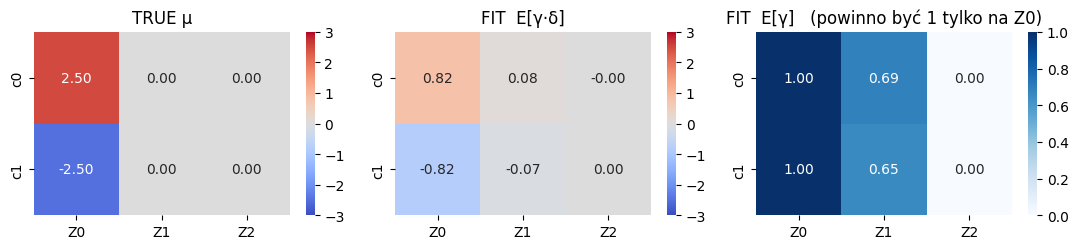

In [8]:
# Heatmapy: TRUE μ vs FIT E[γ·δ] vs FIT E[γ].
fig, axes = plt.subplots(1, 3, figsize=(11, 2.6))
sns.heatmap(mu_1, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-3, vmax=3,
             xticklabels=['Z0','Z1','Z2'], yticklabels=['c0','c1'], ax=axes[0])
axes[0].set_title('TRUE μ')
sns.heatmap(out_c['E_gamma'] * out_c['E_delta'], annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-3, vmax=3,
             xticklabels=['Z0','Z1','Z2'], yticklabels=['c0','c1'], ax=axes[1])
axes[1].set_title('FIT  E[γ·δ]')
sns.heatmap(out_c['E_gamma'], annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
             xticklabels=['Z0','Z1','Z2'], yticklabels=['c0','c1'], ax=axes[2])
axes[2].set_title('FIT  E[γ]   (powinno być 1 tylko na Z0)')
plt.tight_layout(); plt.show()

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:01<00:00, 94.92it/s]


Pretraining FA
Fitting model


100%|██████████| 100/100 [00:01<00:00, 96.16it/s]


Pretraining FA
Fitting model


...

100%|██████████| 100/100 [00:00<00:00, 103.72it/s]


Pretraining FA
Fitting model


100%|██████████| 100/100 [00:00<00:00, 103.90it/s]


Pretraining FA
Fitting model


100%|██████████| 100/100 [00:00<00:00, 101.74it/s]


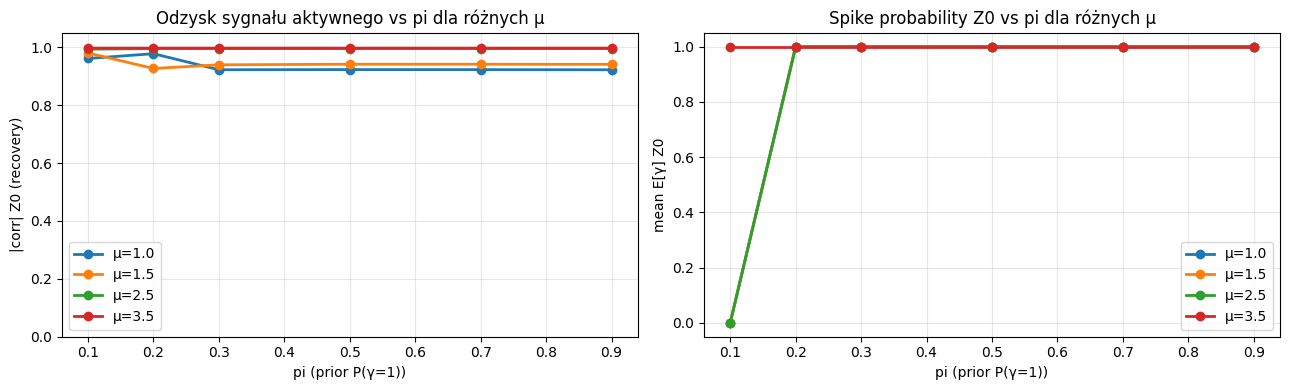

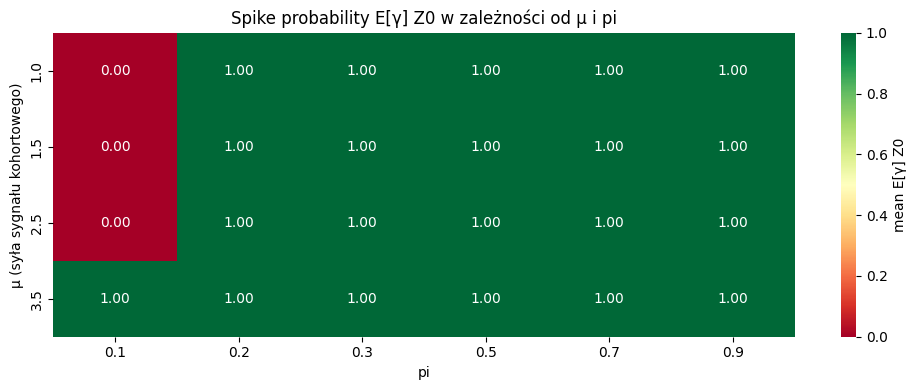

 mu  pi  corr_Z0  gamma_Z0  gamma_Z1  gamma_Z2      elbo
1.0 0.1    0.961       0.0     0.000     0.000 -8014.904
1.0 0.2    0.978       1.0     0.000     0.000 -7929.684
1.0 0.3    0.922       1.0     1.000     1.000 -7943.168
1.0 0.5    0.923       1.0     1.000     1.000 -7940.071
1.0 0.7    0.923       1.0     1.000     1.000 -7938.036
1.0 0.9    0.922       1.0     1.000     1.000 -7936.526
1.5 0.1    0.981       0.0     0.000     0.000 -8081.891
1.5 0.2    0.927       1.0     0.000     1.000 -7970.959
1.5 0.3    0.940       1.0     1.000     0.131 -7972.979
1.5 0.5    0.942       1.0     1.000     0.903 -7972.232
1.5 0.7    0.942       1.0     1.000     0.977 -7970.349
1.5 0.9    0.941       1.0     1.000     0.996 -7968.851
2.5 0.1    0.994       0.0     0.000     0.000 -8170.032
2.5 0.2    0.996       1.0     0.000     0.000 -7986.617
2.5 0.3    0.996       1.0     0.268     0.000 -7989.860
2.5 0.5    0.996       1.0     0.673     0.000 -7989.428
2.5 0.7    0.996       1.0     

In [7]:
def run_experiment_1_sweep(mu_values, pi_grid, sigma=0.5, n_per_cohort=80, seed=0):
    """
    Eksperyment 1 z sweepem wartości μ (siła sygnału) i pi (prior).
    Zwraca DataFrame z wynikami per (mu_val, pi).
    """
    results = []
    for mu_val in mu_values:
        mu = np.array([[mu_val, 0., 0.], [-mu_val, 0., 0.]])
        views, Z, codes = generate_data(mu, sigma=sigma, n_per_cohort=[n_per_cohort, n_per_cohort], seed=seed)
        
        for pi in pi_grid:
            m_c = fit_cohort(views, K=3, pi=pi, seed=seed)
            out_c = evaluate(m_c, Z, K=3)
            
            results.append({
                'mu': mu_val,
                'pi': pi,
                'corr_Z0': out_c['corr'][0],
                'gamma_Z0': out_c['E_gamma'].mean(axis=0)[0],
                'gamma_Z1': out_c['E_gamma'].mean(axis=0)[1],
                'gamma_Z2': out_c['E_gamma'].mean(axis=0)[2],
                'elbo': out_c['elbo']
            })
    
    return pd.DataFrame(results)

# Parametry sweepów
mu_values = [1.0, 1.5, 2.5, 3.5]
pi_grid = [0.1, 0.2, 0.3, 0.5, 0.7, 0.9]

# Uruchom eksperyment
df_sweep = run_experiment_1_sweep(mu_values, pi_grid)

# Wykresy: |corr|_Z0 vs pi dla różnych μ
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Wykres 1: |corr| Z0 (recovery)
for mu_val in mu_values:
    data = df_sweep[df_sweep['mu'] == mu_val]
    axes[0].plot(data['pi'], data['corr_Z0'], 'o-', label=f'μ={mu_val}', linewidth=2)
axes[0].set_xlabel('pi (prior P(γ=1))')
axes[0].set_ylabel('|corr| Z0 (recovery)')
axes[0].set_title('Odzysk sygnału aktywnego vs pi dla różnych μ')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_ylim([0, 1.05])

# Wykres 2: mean E[γ] na Z0 vs pi
for mu_val in mu_values:
    data = df_sweep[df_sweep['mu'] == mu_val]
    axes[1].plot(data['pi'], data['gamma_Z0'], 'o-', label=f'μ={mu_val}', linewidth=2)
axes[1].set_xlabel('pi (prior P(γ=1))')
axes[1].set_ylabel('mean E[γ] Z0')
axes[1].set_title('Spike probability Z0 vs pi dla różnych μ')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_ylim([-0.05, 1.05])

plt.tight_layout()
plt.show()

# Heatmapa: γ_Z0 vs (mu, pi)
pivot_gamma = df_sweep.pivot(index='mu', columns='pi', values='gamma_Z0')
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(pivot_gamma, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1, ax=ax, cbar_kws={'label': 'mean E[γ] Z0'})
ax.set_title('Spike probability E[γ] Z0 w zależności od μ i pi')
ax.set_xlabel('pi')
ax.set_ylabel('μ (syła sygnału kohortowego)')
plt.tight_layout()
plt.show()

print(df_sweep.round(3).to_string(index=False))

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:01<00:00, 95.41it/s]


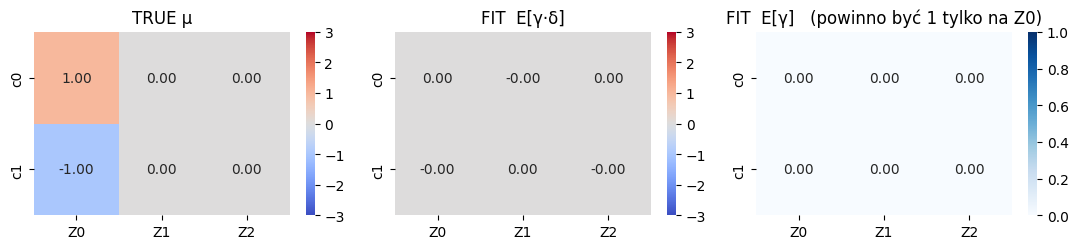

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:01<00:00, 91.05it/s]


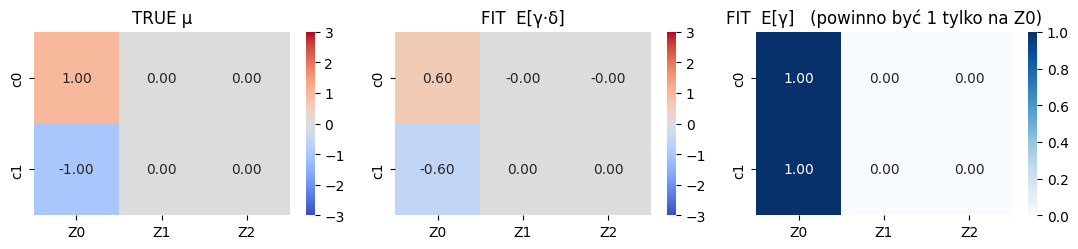

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:00<00:00, 100.95it/s]


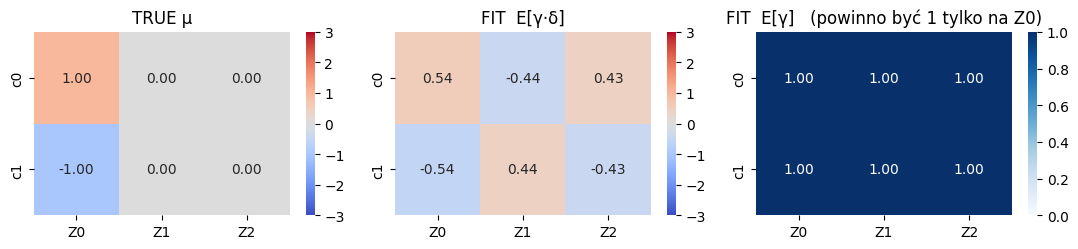

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:01<00:00, 95.96it/s]


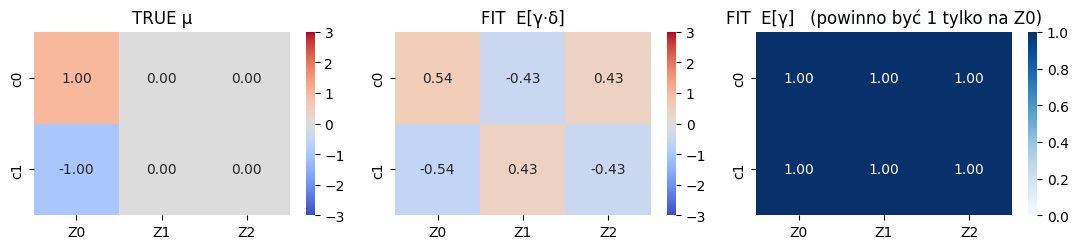

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:01<00:00, 98.35it/s]


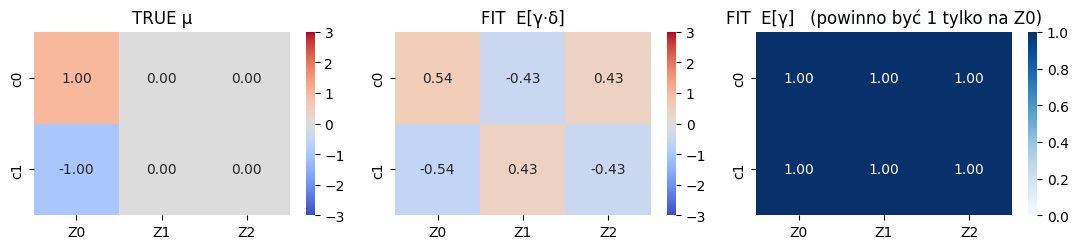

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:00<00:00, 101.90it/s]


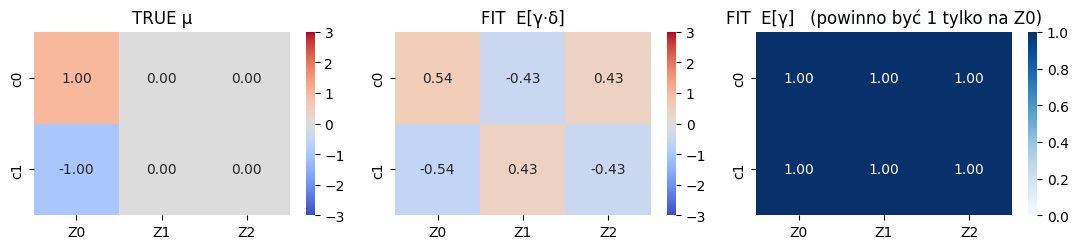

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:00<00:00, 102.49it/s]


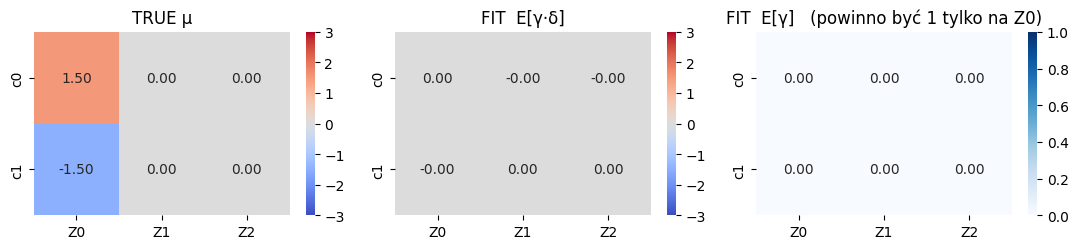

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:00<00:00, 103.10it/s]


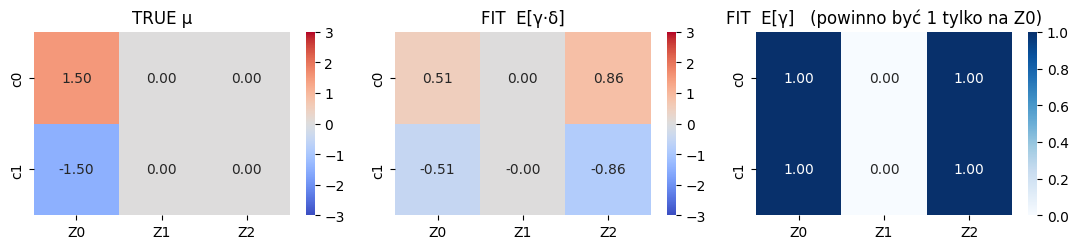

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:00<00:00, 100.95it/s]


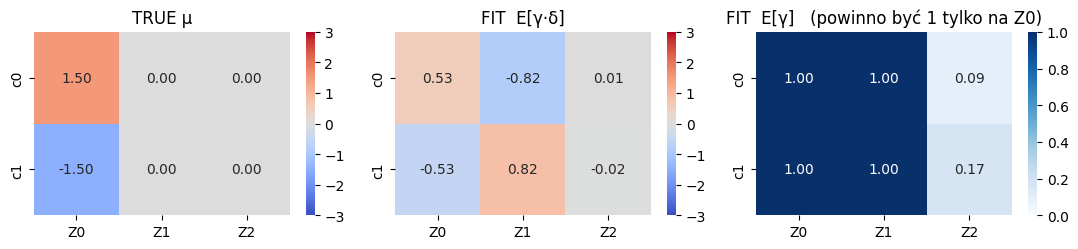

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:00<00:00, 103.34it/s]


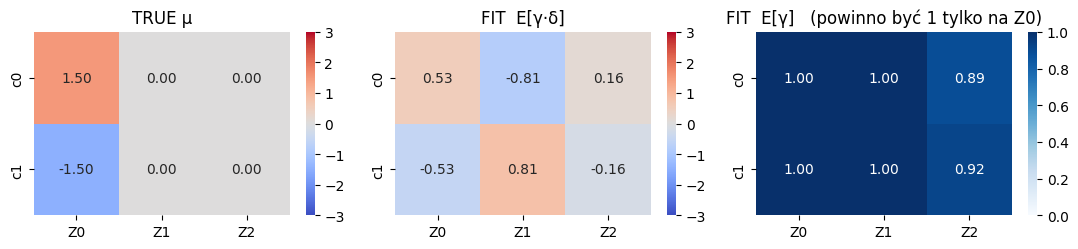

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:00<00:00, 102.23it/s]


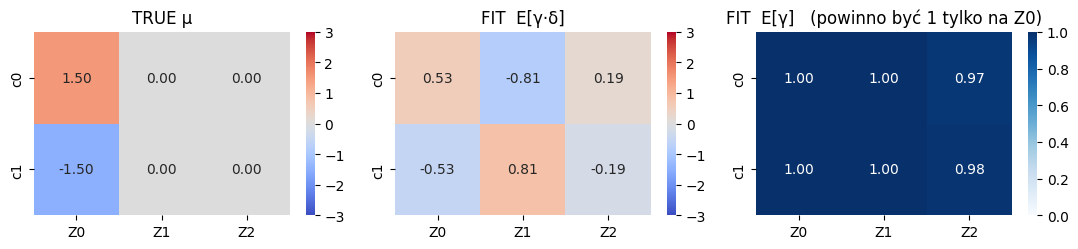

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:00<00:00, 104.37it/s]


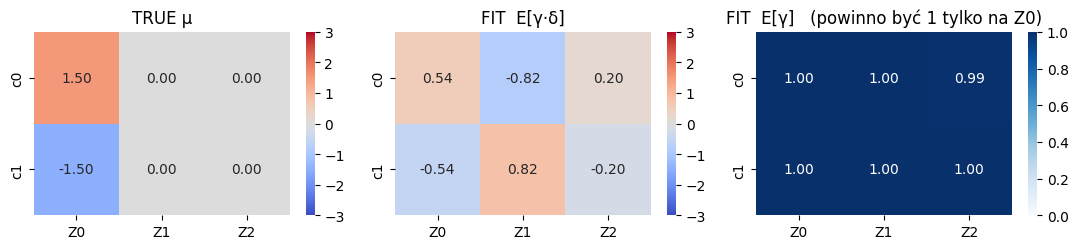

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:00<00:00, 105.32it/s]


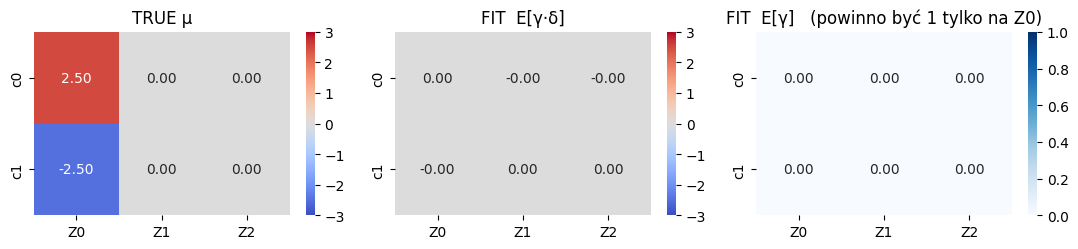

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:00<00:00, 102.26it/s]


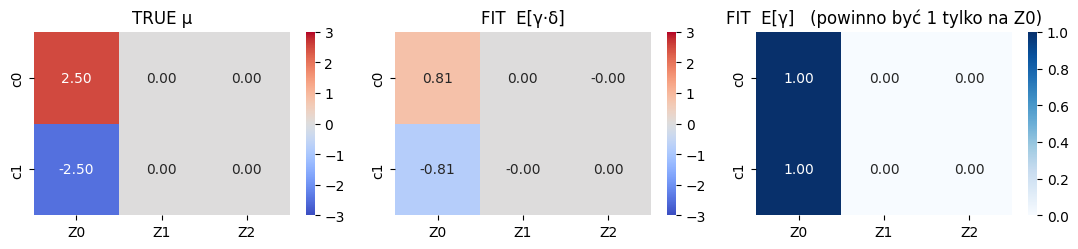

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:00<00:00, 102.04it/s]


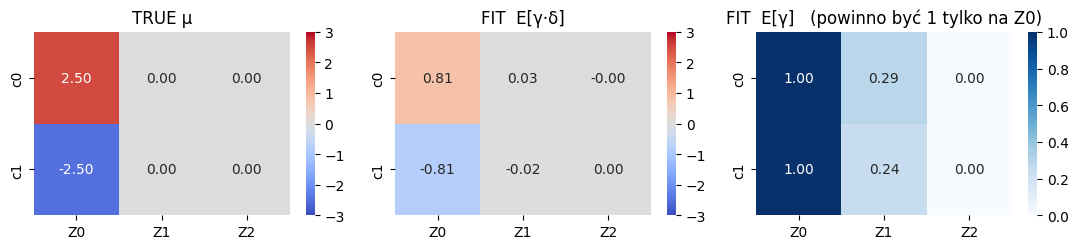

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:00<00:00, 101.59it/s]


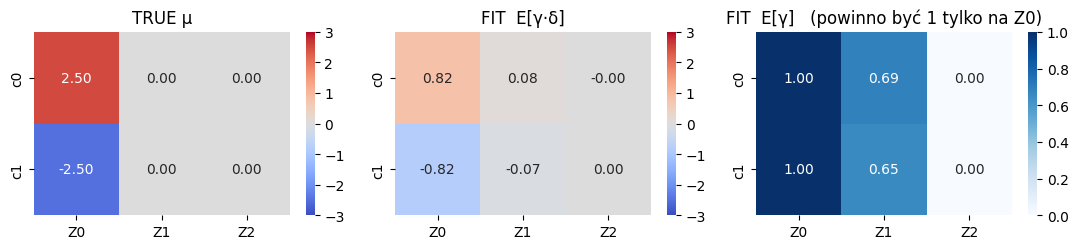

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:00<00:00, 102.22it/s]


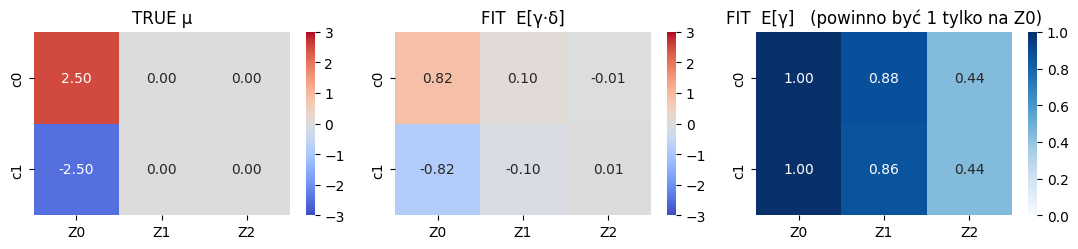

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:00<00:00, 101.29it/s]


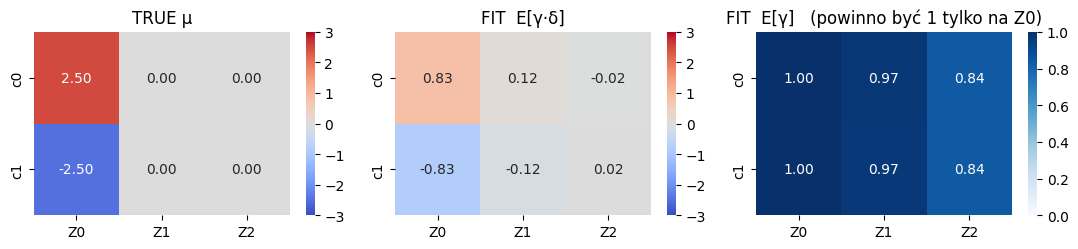

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:00<00:00, 103.28it/s]


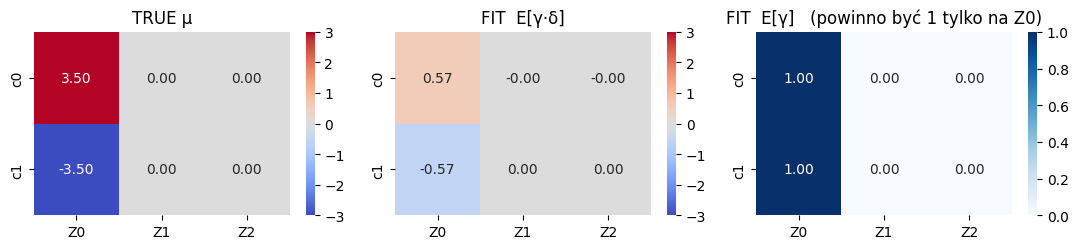

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:00<00:00, 101.92it/s]


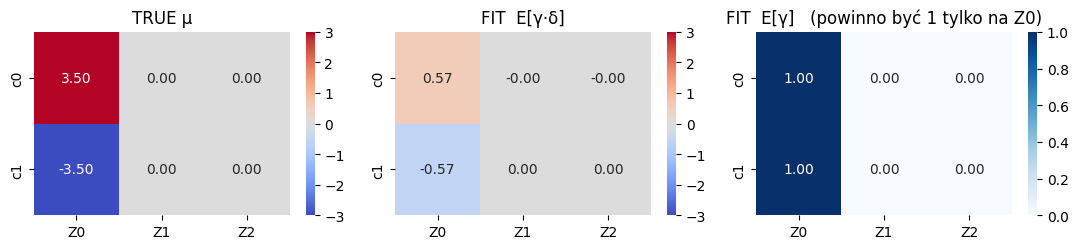

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:00<00:00, 103.94it/s]


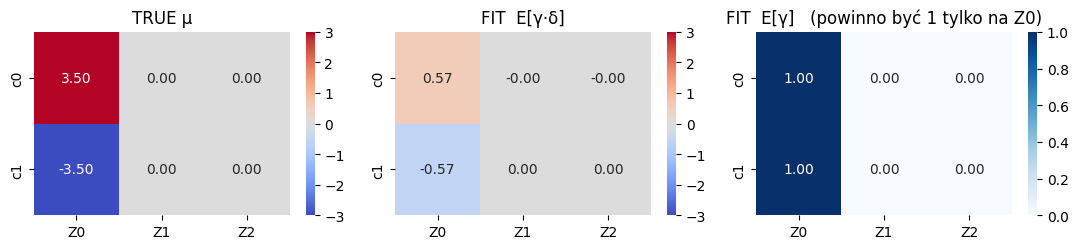

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:00<00:00, 105.27it/s]


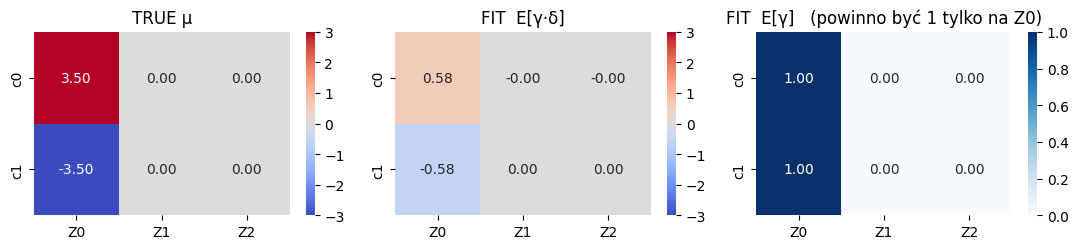

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:00<00:00, 100.07it/s]


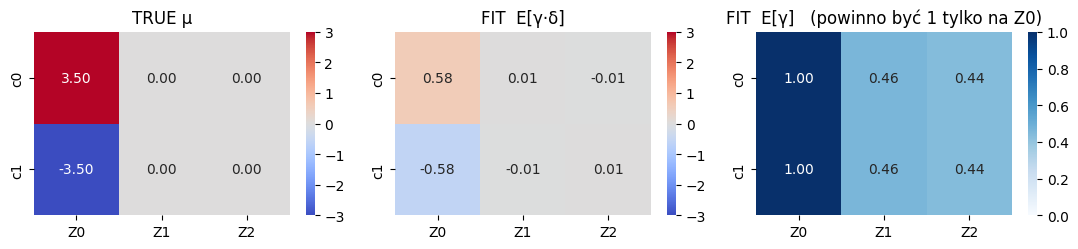

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:00<00:00, 101.55it/s]


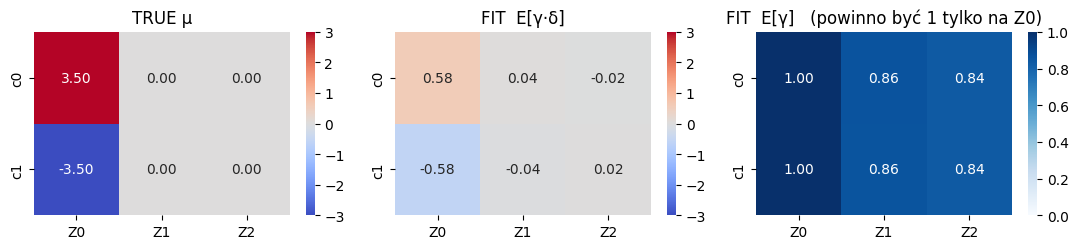

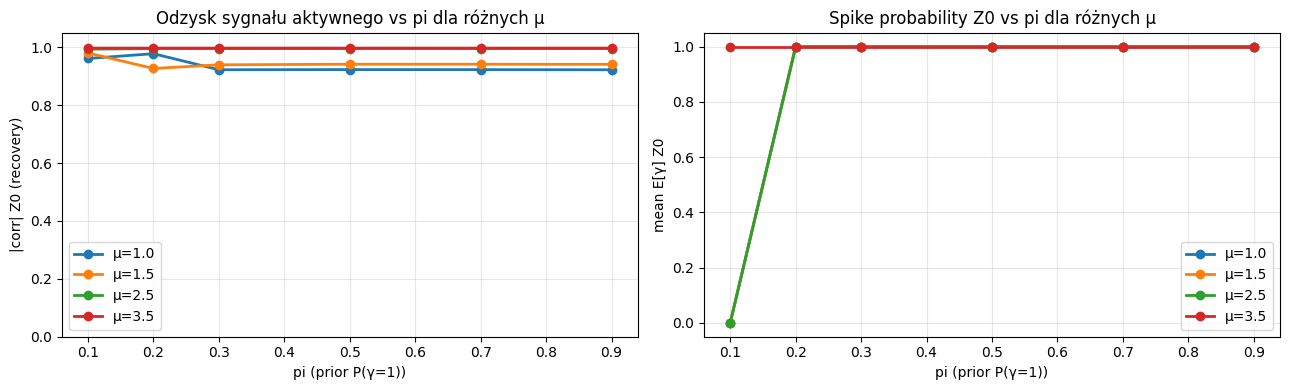

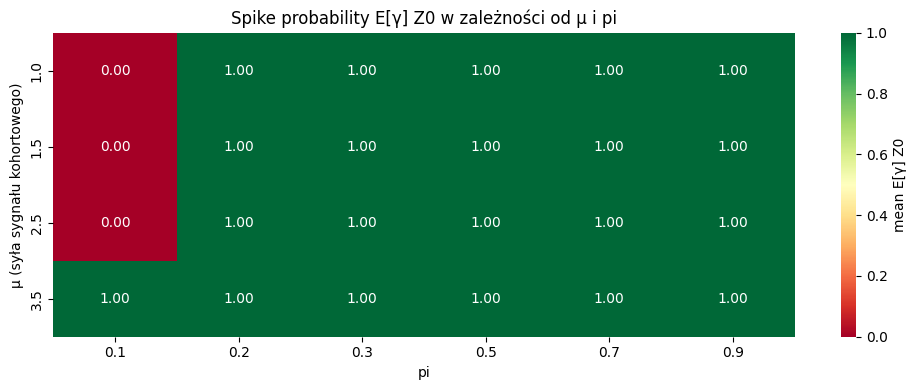

 mu  pi  corr_Z0  gamma_Z0  gamma_Z1  gamma_Z2      elbo
1.0 0.1    0.961       0.0     0.000     0.000 -8014.904
1.0 0.2    0.978       1.0     0.000     0.000 -7929.684
1.0 0.3    0.922       1.0     1.000     1.000 -7943.168
1.0 0.5    0.923       1.0     1.000     1.000 -7940.071
1.0 0.7    0.923       1.0     1.000     1.000 -7938.036
1.0 0.9    0.922       1.0     1.000     1.000 -7936.526
1.5 0.1    0.981       0.0     0.000     0.000 -8081.891
1.5 0.2    0.927       1.0     0.000     1.000 -7970.959
1.5 0.3    0.940       1.0     1.000     0.131 -7972.979
1.5 0.5    0.942       1.0     1.000     0.903 -7972.232
1.5 0.7    0.942       1.0     1.000     0.977 -7970.349
1.5 0.9    0.941       1.0     1.000     0.996 -7968.851
2.5 0.1    0.994       0.0     0.000     0.000 -8170.032
2.5 0.2    0.996       1.0     0.000     0.000 -7986.617
2.5 0.3    0.996       1.0     0.268     0.000 -7989.860
2.5 0.5    0.996       1.0     0.673     0.000 -7989.428
2.5 0.7    0.996       1.0     

In [9]:
def run_experiment_1_sweep(mu_values, pi_grid, sigma=0.5, n_per_cohort=80, seed=0):
    """
    Eksperyment 1 z sweepem wartości μ (siła sygnału) i pi (prior).
    Zwraca DataFrame z wynikami per (mu_val, pi).
    """
    results = []
    for mu_val in mu_values:
        mu = np.array([[mu_val, 0., 0.], [-mu_val, 0., 0.]])
        views, Z, codes = generate_data(mu, sigma=sigma, n_per_cohort=[n_per_cohort, n_per_cohort], seed=seed)
        
        for pi in pi_grid:
            m_c = fit_cohort(views, K=3, pi=pi, seed=seed)
            out_c = evaluate(m_c, Z, K=3)
            
            # Heatmapy: TRUE μ vs FIT E[γ·δ] vs FIT E[γ].
            fig, axes = plt.subplots(1, 3, figsize=(11, 2.6))
            sns.heatmap(mu, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-3, vmax=3,
                         xticklabels=['Z0','Z1','Z2'], yticklabels=['c0','c1'], ax=axes[0])
            axes[0].set_title('TRUE μ')
            sns.heatmap(out_c['E_gamma'] * out_c['E_delta'], annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-3, vmax=3,
                         xticklabels=['Z0','Z1','Z2'], yticklabels=['c0','c1'], ax=axes[1])
            axes[1].set_title('FIT  E[γ·δ]')
            sns.heatmap(out_c['E_gamma'], annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
                         xticklabels=['Z0','Z1','Z2'], yticklabels=['c0','c1'], ax=axes[2])
            axes[2].set_title('FIT  E[γ]   (powinno być 1 tylko na Z0)')
            plt.tight_layout(); plt.show()
            
            results.append({
                'mu': mu_val,
                'pi': pi,
                'corr_Z0': out_c['corr'][0],
                'gamma_Z0': out_c['E_gamma'].mean(axis=0)[0],
                'gamma_Z1': out_c['E_gamma'].mean(axis=0)[1],
                'gamma_Z2': out_c['E_gamma'].mean(axis=0)[2],
                'elbo': out_c['elbo']
            })
    
    return pd.DataFrame(results)

# Parametry sweepów
mu_values = [1.0, 1.5, 2.5, 3.5]
pi_grid = [0.1, 0.2, 0.3, 0.5, 0.7, 0.9]

# Uruchom eksperyment
df_sweep = run_experiment_1_sweep(mu_values, pi_grid)

# Wykresy: |corr|_Z0 vs pi dla różnych μ
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Wykres 1: |corr| Z0 (recovery)
for mu_val in mu_values:
    data = df_sweep[df_sweep['mu'] == mu_val]
    axes[0].plot(data['pi'], data['corr_Z0'], 'o-', label=f'μ={mu_val}', linewidth=2)
axes[0].set_xlabel('pi (prior P(γ=1))')
axes[0].set_ylabel('|corr| Z0 (recovery)')
axes[0].set_title('Odzysk sygnału aktywnego vs pi dla różnych μ')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_ylim([0, 1.05])

# Wykres 2: mean E[γ] na Z0 vs pi
for mu_val in mu_values:
    data = df_sweep[df_sweep['mu'] == mu_val]
    axes[1].plot(data['pi'], data['gamma_Z0'], 'o-', label=f'μ={mu_val}', linewidth=2)
axes[1].set_xlabel('pi (prior P(γ=1))')
axes[1].set_ylabel('mean E[γ] Z0')
axes[1].set_title('Spike probability Z0 vs pi dla różnych μ')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_ylim([-0.05, 1.05])

plt.tight_layout()
plt.show()

# Heatmapa: γ_Z0 vs (mu, pi)
pivot_gamma = df_sweep.pivot(index='mu', columns='pi', values='gamma_Z0')
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(pivot_gamma, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1, ax=ax, cbar_kws={'label': 'mean E[γ] Z0'})
ax.set_title('Spike probability E[γ] Z0 w zależności od μ i pi')
ax.set_xlabel('pi')
ax.set_ylabel('μ (syła sygnału kohortowego)')
plt.tight_layout()
plt.show()

print(df_sweep.round(3).to_string(index=False))

## Eksperyment 2 — trzy aktywne + dwa ciche

Setup z `cohort_experiments_report` Exp 1: K=5, C=2, N=60 kohortę, μ z malejącą amplitudą (±1.5, ±1.2, ±0.8, 0, 0). `pi=0.5`.

Co sprawdzamy: czy γ aktywuje Z0–Z2 (active); γ → 0 na Z3, Z4 (silent). δ malejąca amplituda.

In [5]:
# Generujemy dane: 3 aktywne + 2 ciche.
mu_2 = np.array([[ 1.5, -1.2,  0.8, 0., 0.],
                  [-1.5,  1.2, -0.8, 0., 0.]])
views_2, Z_2, codes_2 = generate_data(mu_2, sigma=0.8, n_per_cohort=[60, 60], seed=0)

m2_c = fit_cohort(views_2, K=5, pi=0.5)
m2_b = fit_baseline(views_2, K=5)
out2_c = evaluate(m2_c, Z_2, K=5)
out2_b = evaluate(m2_b, Z_2, K=5)

tab2 = pd.DataFrame({
    'true_active': [True, True, True, False, False],
    'true_max|μ|': [1.5, 1.2, 0.8, 0.0, 0.0],
    '|corr|_cohort':   out2_c['corr'].round(3),
    '|corr|_baseline': out2_b['corr'].round(3),
    'mean E[γ]':       out2_c['E_gamma'].mean(axis=0).round(3),
    'max|E[δ]|':       np.abs(out2_c['E_delta']).max(axis=0).round(3),
}, index=[f'Z{k}' for k in range(5)])
print(tab2.to_string())
print(f"\nELBO  cohort = {out2_c['elbo']:.1f},  baseline = {out2_b['elbo']:.1f}")

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:01<00:00, 65.00it/s]


Pretraining FA
Fitting model


100%|██████████| 100/100 [00:01<00:00, 72.70it/s]

    true_active  true_max|μ|  |corr|_cohort  |corr|_baseline  mean E[γ]  max|E[δ]|
Z0         True          1.5          0.968            0.957      1.000      0.462
Z1         True          1.2          0.663            0.485      0.999      0.280
Z2         True          0.8          0.918            0.657      1.000      0.372
Z3        False          0.0          0.539            0.575      0.000      0.000
Z4        False          0.0          0.744            0.643      0.000      0.000

ELBO  cohort = -7044.1,  baseline = -7088.4


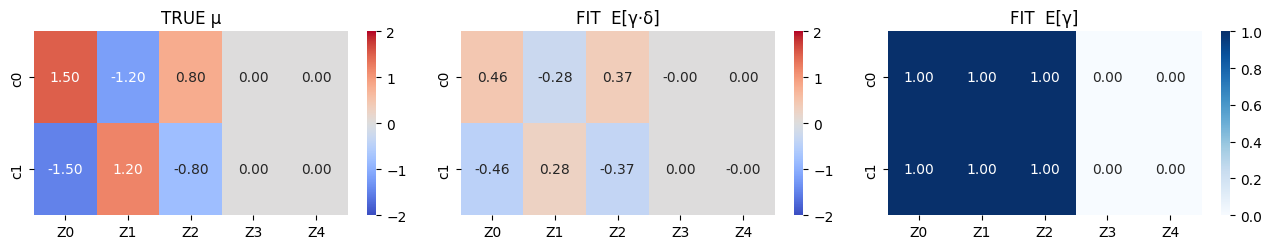

In [6]:
# Heatmapy odzyskanej struktury kohortowej.
cols = [f'Z{k}' for k in range(5)]
fig, axes = plt.subplots(1, 3, figsize=(13, 2.6))
sns.heatmap(mu_2, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-2, vmax=2,
             xticklabels=cols, yticklabels=['c0','c1'], ax=axes[0])
axes[0].set_title('TRUE μ')
sns.heatmap(out2_c['E_gamma'] * out2_c['E_delta'], annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-2, vmax=2,
             xticklabels=cols, yticklabels=['c0','c1'], ax=axes[1])
axes[1].set_title('FIT  E[γ·δ]')
sns.heatmap(out2_c['E_gamma'], annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
             xticklabels=cols, yticklabels=['c0','c1'], ax=axes[2])
axes[2].set_title('FIT  E[γ]')
plt.tight_layout(); plt.show()

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:01<00:00, 64.51it/s]


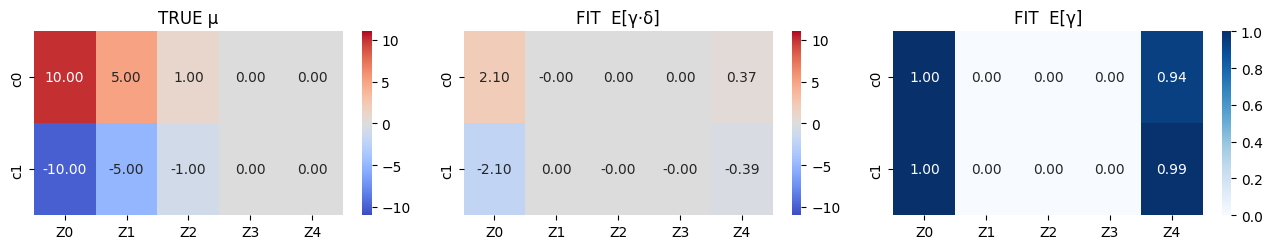

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:01<00:00, 63.92it/s]


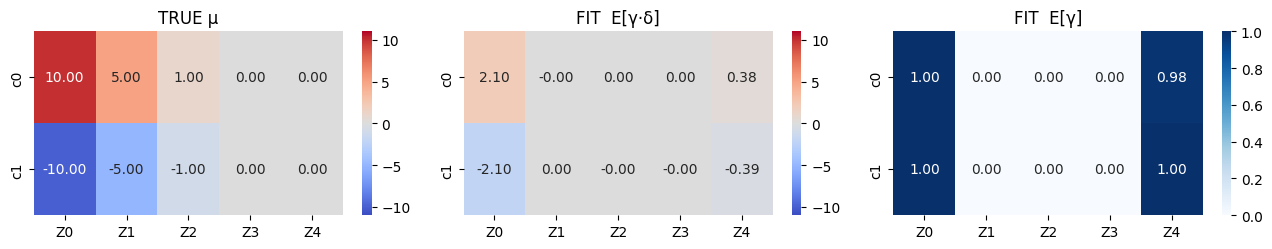

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:01<00:00, 64.87it/s]


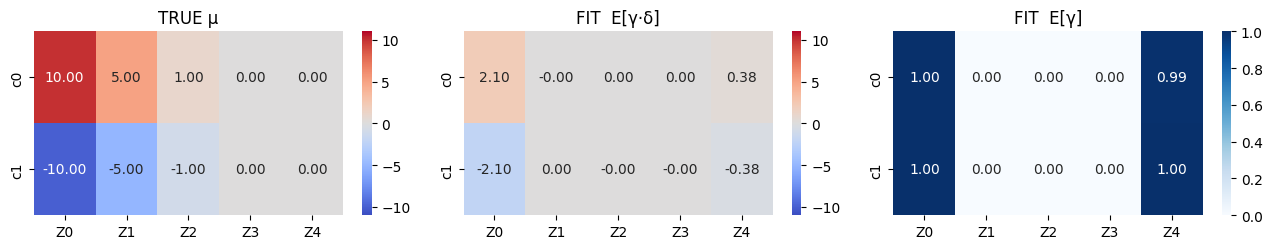

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:01<00:00, 67.49it/s]


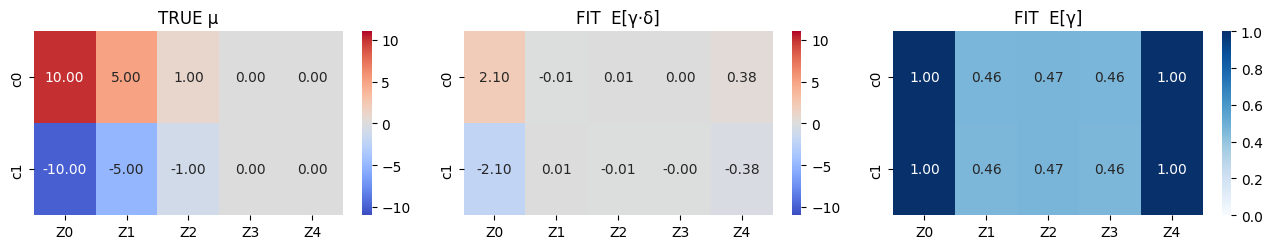

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:01<00:00, 69.94it/s]


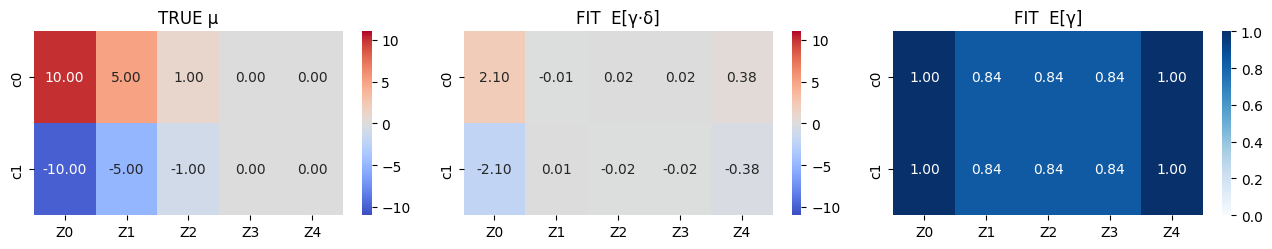

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:01<00:00, 69.86it/s]


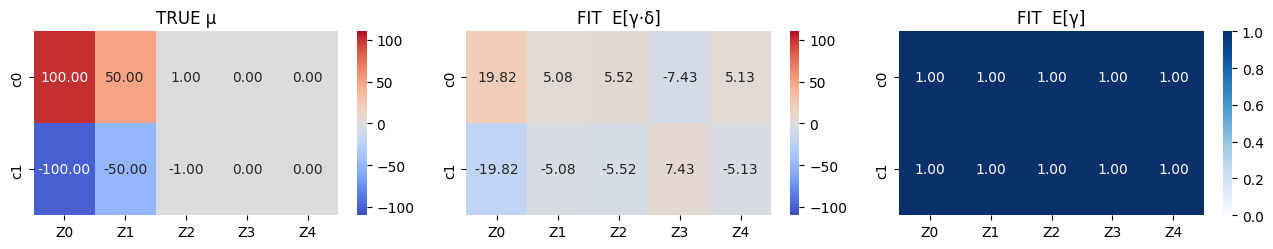

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:01<00:00, 68.60it/s]


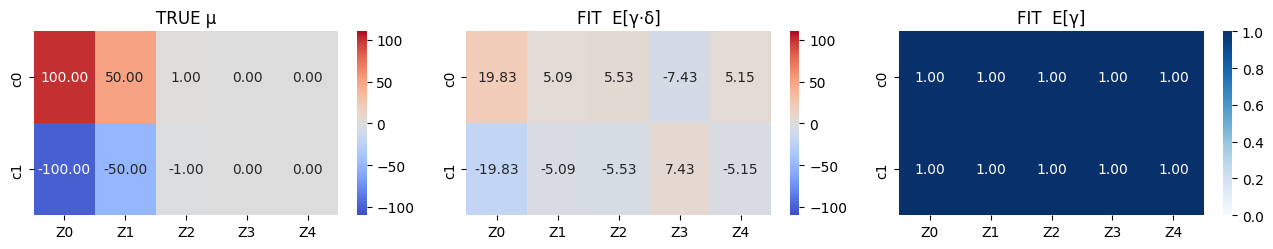

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:01<00:00, 70.41it/s]


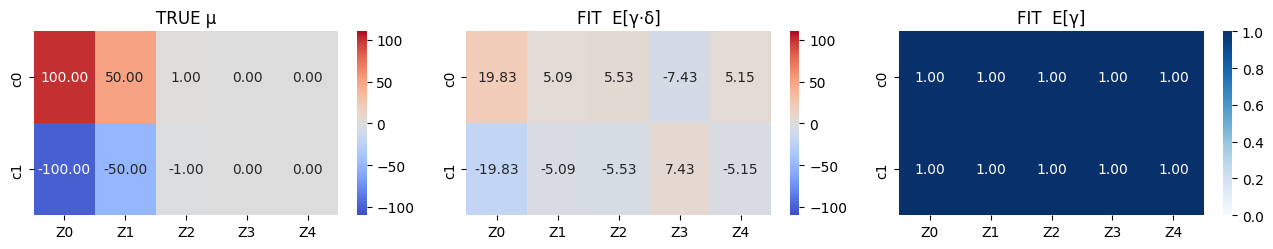

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:01<00:00, 68.37it/s]


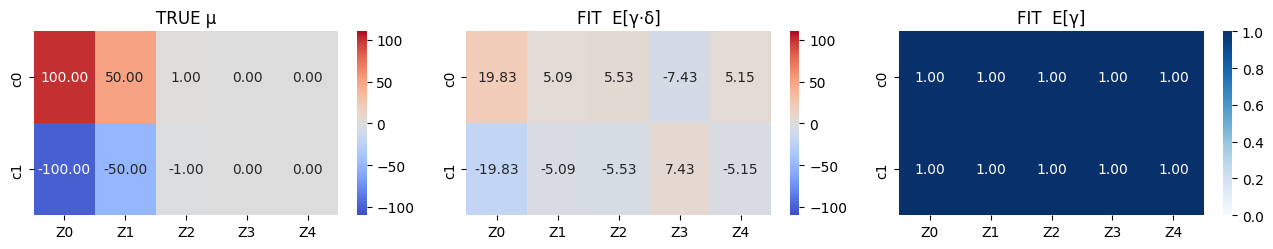

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:01<00:00, 70.57it/s]


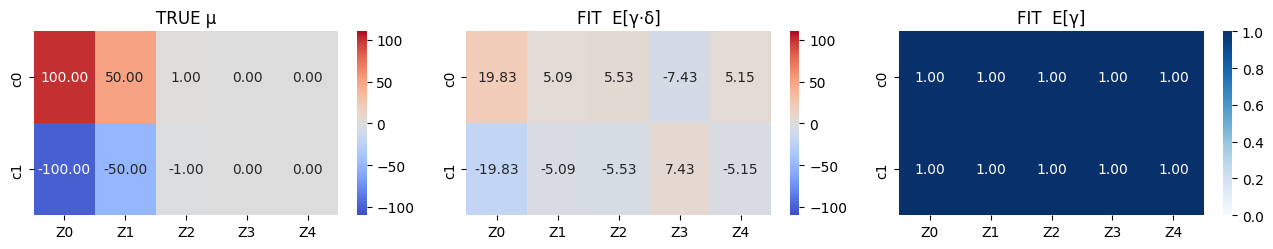

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:01<00:00, 70.28it/s]


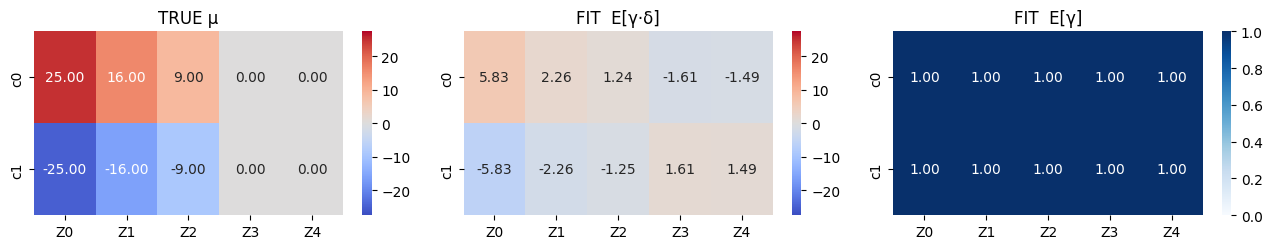

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:01<00:00, 69.05it/s]


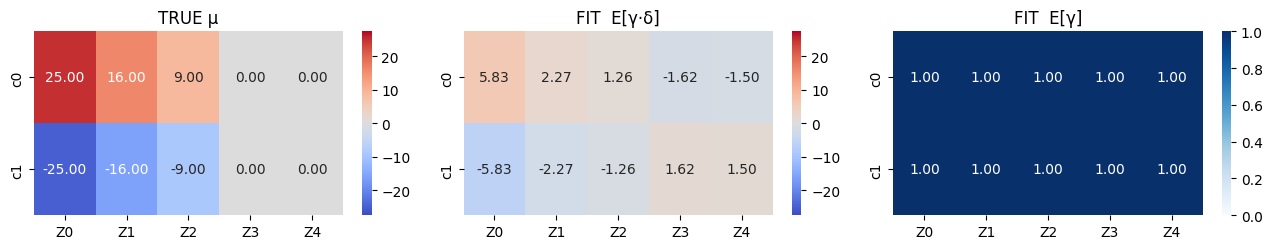

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:01<00:00, 68.37it/s]


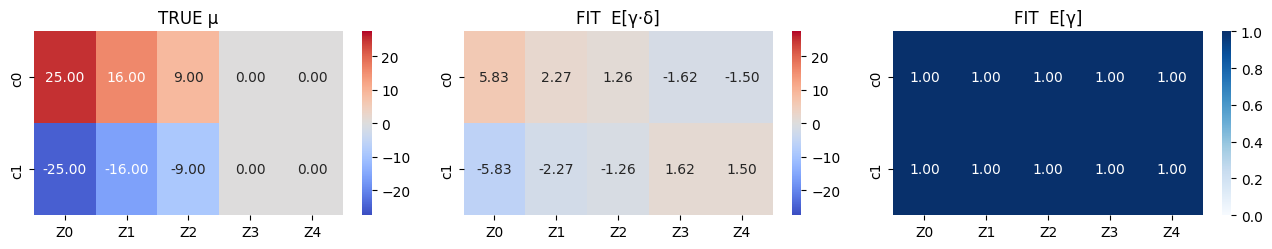

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:01<00:00, 70.72it/s]


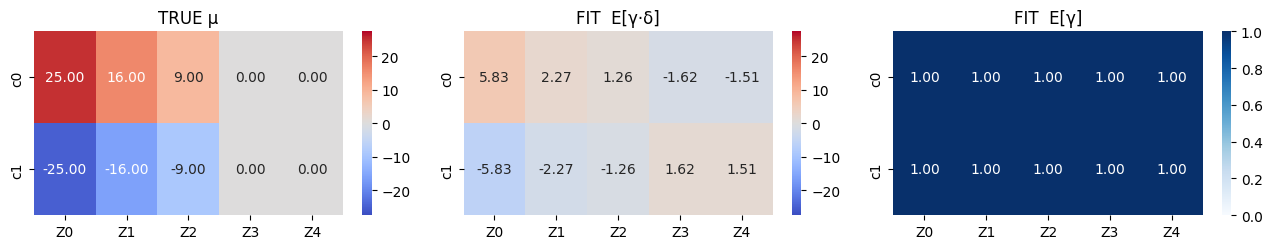

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:01<00:00, 71.05it/s]


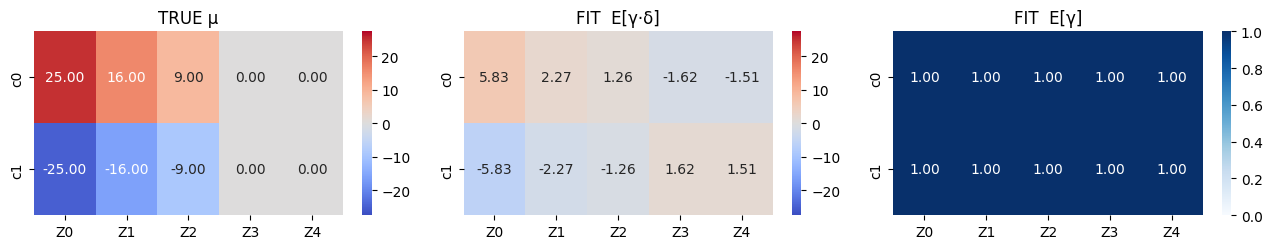

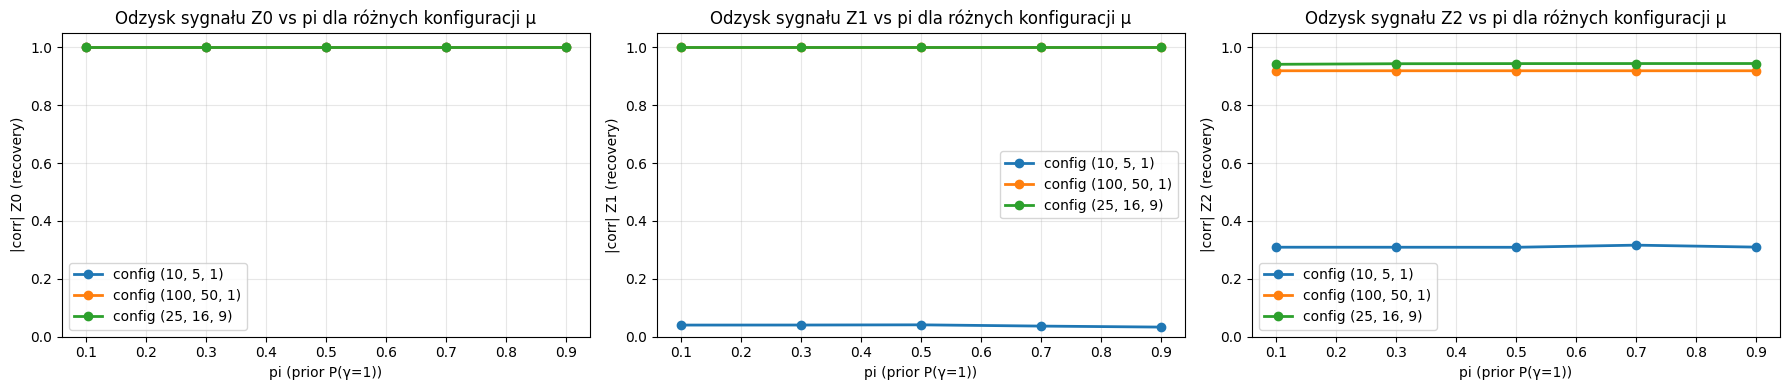

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:01<00:00, 69.39it/s]


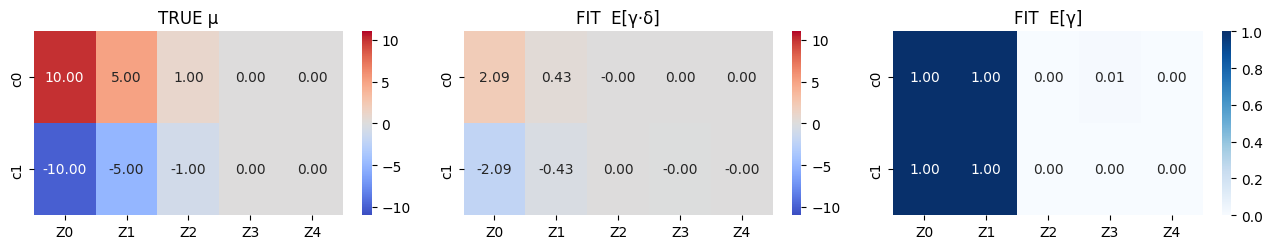

      config  pi  corr_Z0  corr_Z1  corr_Z2  gamma_Z0  gamma_Z1  gamma_Z2  gamma_Z3  gamma_Z4      elbo
  (10, 5, 1) 0.1    0.999    0.040    0.309       1.0     0.000     0.000     0.000     0.965 -6817.656
  (10, 5, 1) 0.3    0.999    0.040    0.309       1.0     0.000     0.000     0.000     0.990 -6814.959
  (10, 5, 1) 0.5    0.999    0.041    0.309       1.0     0.000     0.000     0.000     0.995 -6815.020
  (10, 5, 1) 0.7    0.999    0.037    0.316       1.0     0.462     0.465     0.460     0.998 -6819.218
  (10, 5, 1) 0.9    0.999    0.033    0.310       1.0     0.837     0.837     0.838     0.999 -6819.318
(100, 50, 1) 0.1    1.000    1.000    0.919       1.0     1.000     1.000     1.000     1.000 -8335.854
(100, 50, 1) 0.3    1.000    1.000    0.919       1.0     1.000     1.000     1.000     1.000 -8325.115
(100, 50, 1) 0.5    1.000    1.000    0.919       1.0     1.000     1.000     1.000     1.000 -8320.075
(100, 50, 1) 0.7    1.000    1.000    0.919       1.0     1.000 

In [13]:
def run_experiment_2_sweep(mu_configs, pi_grid, sigma=0.5, n_per_cohort=60, seed=0):
    """
    Eksperyment 2 z sweepem różnych konfiguracji μ (siła sygnału dla Z0, Z1, Z2) i pi (prior).
    Zwraca DataFrame z wynikami per (config, pi).
    """
    results = []
    for config in mu_configs:
        a, b, c = config
        mu = np.array([[a, b, c, 0., 0.], [-a, -b, -c, 0., 0.]])
        views, Z, codes = generate_data(mu, sigma=sigma, n_per_cohort=[n_per_cohort, n_per_cohort], seed=seed)
        
        for pi in pi_grid:
            m_c = fit_cohort(views, K=5, pi=pi, seed=seed)
            out_c = evaluate(m_c, Z, K=5)
            
            results.append({
                'config': str(config),
                'pi': pi,
                'corr_Z0': out_c['corr'][0],
                'corr_Z1': out_c['corr'][1],
                'corr_Z2': out_c['corr'][2],
                'gamma_Z0': out_c['E_gamma'].mean(axis=0)[0], 
                'gamma_Z1': out_c['E_gamma'].mean(axis=0)[1],
                'gamma_Z2': out_c['E_gamma'].mean(axis=0)[2],
                'gamma_Z3': out_c['E_gamma'].mean(axis=0)[3],
                'gamma_Z4': out_c['E_gamma'].mean(axis=0)[4],
                'elbo': out_c['elbo']
            })
            # Heatmapy odzyskanej struktury kohortowej.
            cols = [f'Z{k}' for k in range(5)]
            fig, axes = plt.subplots(1, 3, figsize=(13, 2.6))
            max_mu = max(a, b, c)
            sns.heatmap(mu, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-max_mu*1.1, vmax=max_mu*1.1,
                            xticklabels=cols, yticklabels=['c0','c1'], ax=axes[0])
            axes[0].set_title('TRUE μ')
            sns.heatmap(out_c['E_gamma'] * out_c['E_delta'], annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-max_mu*1.1, vmax=max_mu*1.1,
                            xticklabels=cols, yticklabels=['c0','c1'], ax=axes[1])
            axes[1].set_title('FIT  E[γ·δ]')
            sns.heatmap(out_c['E_gamma'], annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
                            xticklabels=cols, yticklabels=['c0','c1'], ax=axes[2])
            axes[2].set_title('FIT  E[γ]')
            plt.tight_layout(); plt.show()
    
    return pd.DataFrame(results)

# Konfiguracje μ: (Z0, Z1, Z2)
mu_configs = [(10, 5, 1), (100, 50, 1), (25, 16, 9)]
pi_grid = [0.1, 0.3, 0.5, 0.7, 0.9]

# Uruchom eksperyment
df_sweep_2 = run_experiment_2_sweep(mu_configs, pi_grid)

# Wykresy: |corr| dla Z0, Z1, Z2 vs pi dla różnych konfiguracji
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for i, z in enumerate(['Z0', 'Z1', 'Z2']):
    for config in mu_configs:
        data = df_sweep_2[df_sweep_2['config'] == str(config)]
        axes[i].plot(data['pi'], data[f'corr_{z}'], 'o-', label=f'config {config}', linewidth=2)
    axes[i].set_xlabel('pi (prior P(γ=1))')
    axes[i].set_ylabel(f'|corr| {z} (recovery)')
    axes[i].set_title(f'Odzysk sygnału {z} vs pi dla różnych konfiguracji μ')
    axes[i].legend()
    axes[i].grid(alpha=0.3)
    axes[i].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

# Heatmapy dla jednej konfiguracji, np. (10,5,1), dla przykładu
config_example = (10, 5, 1)
mu_example = np.array([[config_example[0], config_example[1], config_example[2], 0., 0.], [-config_example[0], -config_example[1], -config_example[2], 0., 0.]])
views_example, Z_example, codes_example = generate_data(mu_example, sigma=0.8, n_per_cohort=[60, 60], seed=0)
m_example = fit_cohort(views_example, K=5, pi=0.5)
out_example = evaluate(m_example, Z_example, K=5)

cols = [f'Z{k}' for k in range(5)]
fig, axes = plt.subplots(1, 3, figsize=(13, 2.6))
sns.heatmap(mu_example, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-max(config_example)*1.1, vmax=max(config_example)*1.1,
             xticklabels=cols, yticklabels=['c0','c1'], ax=axes[0])
axes[0].set_title('TRUE μ')
sns.heatmap(out_example['E_gamma'] * out_example['E_delta'], annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-max(config_example)*1.1, vmax=max(config_example)*1.1,
             xticklabels=cols, yticklabels=['c0','c1'], ax=axes[1])
axes[1].set_title('FIT  E[γ·δ]')
sns.heatmap(out_example['E_gamma'], annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
             xticklabels=cols, yticklabels=['c0','c1'], ax=axes[2])
axes[2].set_title('FIT  E[γ]')
plt.tight_layout(); plt.show()

print(df_sweep_2.round(3).to_string(index=False))

## Eksperyment 3 — wpływ `pi`

Na danych z eksperymentu 2 (3 aktywne + 2 ciche), sweep `pi ∈ {0.1, 0.3, 0.5, 0.7, 0.9}`.

Co sprawdzamy: jak zmienia się `mean E[γ]` per czynnik. Spodziewamy się, że Z0/Z1 (silny sygnał) będą stabilne w całym zakresie, a słabsze (Z2) i ciche (Z3, Z4) zaczną fałszywie aktywować dla wysokich `pi`.

In [7]:
# Sweep pi: zbieramy mean E[γ] per czynnik.
pi_grid = [0.1, 0.3, 0.5, 0.7, 0.9]
rows = []
for pi in pi_grid:
    m = fit_cohort(views_2, K=5, pi=pi)
    out = evaluate(m, Z_2, K=5)
    rows.append({'pi': pi,
                  **{f'γ_Z{k}': out['E_gamma'].mean(axis=0)[k] for k in range(5)},
                  **{f'corr_Z{k}': out['corr'][k] for k in range(5)},
                  'elbo': out['elbo']})
df_pi = pd.DataFrame(rows)
print(df_pi.round(3).to_string(index=False))

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:01<00:00, 64.36it/s]


Pretraining FA
Fitting model


100%|██████████| 100/100 [00:01<00:00, 67.97it/s]


Pretraining FA
Fitting model


...

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:01<00:00, 70.38it/s]


Pretraining FA
Fitting model


100%|██████████| 100/100 [00:01<00:00, 70.75it/s]

 pi  γ_Z0  γ_Z1  γ_Z2  γ_Z3  γ_Z4  corr_Z0  corr_Z1  corr_Z2  corr_Z3  corr_Z4      elbo
0.1   1.0 0.000   1.0 0.000 0.000    0.978    0.269    0.918    0.750    0.751 -7042.720
0.3   1.0 0.000   1.0 0.000 0.000    0.978    0.268    0.918    0.750    0.751 -7039.745
0.5   1.0 0.999   1.0 0.000 0.000    0.968    0.663    0.918    0.539    0.744 -7044.065
0.7   1.0 1.000   1.0 0.569 0.436    0.965    0.682    0.921    0.543    0.740 -7046.834
0.9   1.0 1.000   1.0 0.964 0.837    0.962    0.680    0.926    0.548    0.733 -7046.003


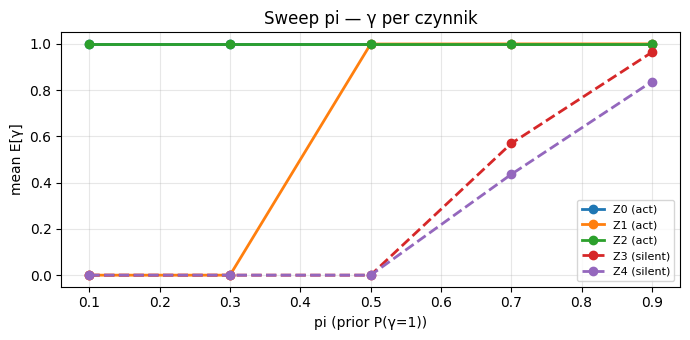

In [8]:
# Wykres: γ per czynnik vs pi (linie ciągłe = aktywne, przerywane = ciche).
fig, ax = plt.subplots(figsize=(7, 3.5))
true_active_2 = [True, True, True, False, False]
for k in range(5):
    ls = '-' if true_active_2[k] else '--'
    ax.plot(df_pi['pi'], df_pi[f'γ_Z{k}'], 'o-' if true_active_2[k] else 'o--',
             label=f'Z{k}{" (act)" if true_active_2[k] else " (silent)"}', linewidth=2)
ax.set_xlabel('pi (prior P(γ=1))'); ax.set_ylabel('mean E[γ]')
ax.set_title('Sweep pi — γ per czynnik')
ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_ylim(-0.05, 1.05)
plt.tight_layout(); plt.show()

## Eksperyment 4 — wpływ `N` (rozmiaru próby)

Setup z eksp 2, pi=0.5. Sweep N_per_cohort ∈ {20, 40, 80, 160}, **3 seedy** dla stabilności.

**Co sprawdzamy:** średnia |corr| na aktywnych vs N. Spodziewamy się monotonicznego wzrostu z N.

In [9]:
# Sweep N × seedy: zbieramy mean |corr| na aktywnych Z0-Z2.
N_grid = [20, 40, 80, 160]
rows = []
for n in N_grid:
    for seed in range(5):
        v_, Z_, _ = generate_data(mu_2, sigma=0.8, n_per_cohort=[n, n], seed=seed)
        m_ = fit_cohort(v_, K=5, pi=0.5, seed=seed)
        out = evaluate(m_, Z_, K=5)
        rows.append({'N': n, 'seed': seed,
                      'mean_corr_active': float(out['corr'][:3].mean()),
                      'mean_gamma_active': float(out['E_gamma'].mean(axis=0)[:3].mean()),
                      'mean_gamma_silent': float(out['E_gamma'].mean(axis=0)[3:].mean()),
                      'elbo': out['elbo']})
df_N = pd.DataFrame(rows)
print(df_N.groupby('N')[['mean_corr_active','mean_gamma_active','mean_gamma_silent']].agg(['mean','std']).round(3))

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:01<00:00, 69.42it/s]


Pretraining FA
Fitting model


100%|██████████| 100/100 [00:01<00:00, 69.86it/s]


Pretraining FA
Fitting model


...

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:01<00:00, 55.18it/s]


Pretraining FA
Fitting model


100%|██████████| 100/100 [00:01<00:00, 58.89it/s]

    mean_corr_active        mean_gamma_active        mean_gamma_silent       
                mean    std              mean    std              mean    std
N                                                                            
20             0.568  0.072             0.406  0.113             0.190  0.260
40             0.664  0.061             0.582  0.143             0.257  0.244
80             0.751  0.094             0.865  0.181             0.228  0.435
160            0.734  0.058             0.835  0.157             0.500  0.500


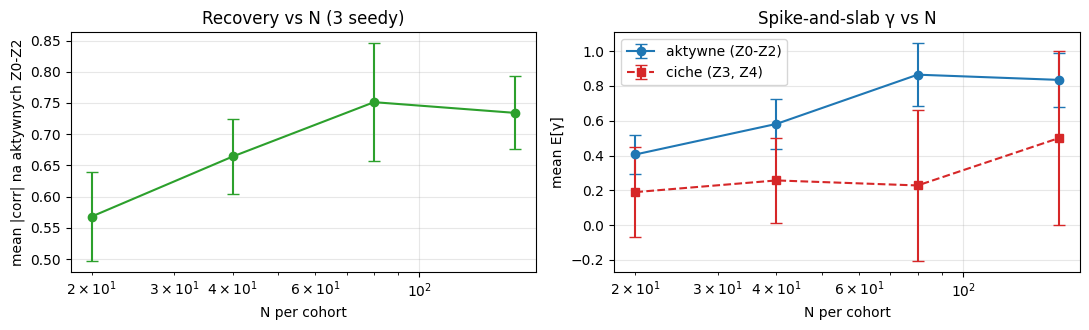

In [10]:
# Wykres: mean |corr| na aktywnych ± std vs N.
agg = df_N.groupby('N').agg({'mean_corr_active': ['mean', 'std'],
                                'mean_gamma_active': ['mean', 'std'],
                                'mean_gamma_silent': ['mean', 'std']})
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].errorbar(agg.index, agg[('mean_corr_active','mean')], yerr=agg[('mean_corr_active','std')],
                  fmt='o-', capsize=4, color='C2')
axes[0].set_xlabel('N per cohort'); axes[0].set_ylabel('mean |corr| na aktywnych Z0-Z2')
axes[0].set_title('Recovery vs N (3 seedy)'); axes[0].grid(alpha=0.3); axes[0].set_xscale('log')

axes[1].errorbar(agg.index, agg[('mean_gamma_active','mean')], yerr=agg[('mean_gamma_active','std')],
                  fmt='o-', capsize=4, color='C0', label='aktywne (Z0-Z2)')
axes[1].errorbar(agg.index, agg[('mean_gamma_silent','mean')], yerr=agg[('mean_gamma_silent','std')],
                  fmt='s--', capsize=4, color='C3', label='ciche (Z3, Z4)')
axes[1].set_xlabel('N per cohort'); axes[1].set_ylabel('mean E[γ]')
axes[1].set_title('Spike-and-slab γ vs N'); axes[1].legend(); axes[1].grid(alpha=0.3); axes[1].set_xscale('log')
plt.tight_layout(); plt.show()